In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/TugasAkhirKayla"

/content/drive/MyDrive/TugasAkhirKayla


In [3]:
!pip install pydicom
!pip install PyWavelets
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.3 MB/s eta 0:00:00


In [4]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
import pywt

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

In [5]:
import sys

PROJECT_DIR = "/content/drive/MyDrive/TugasAkhirKayla"

DATASET_PATH = os.path.join(PROJECT_DIR, "Dataset")
MODULE_PATH = os.path.join(PROJECT_DIR, "Modules")
OUTPUT_PATH = os.path.join(PROJECT_DIR, "Output")
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

In [6]:
# Import semua module
from Modules import (
    preprocessing,
    dwt,
    energy,
    adaptive,
    embedding,
    extraction,
    evaluation,
    utils,
)

# Reload module agar perubahan langsung terbaca
import importlib

modules = [
    preprocessing,
    dwt,
    energy,
    adaptive,
    embedding,
    extraction,
    evaluation,
    utils,
]

for module in modules:
    importlib.reload(module)

print("Semua modul berhasil dimuat.")

Semua modul berhasil dimuat.


In [7]:
print(DATASET_PATH)

/content/drive/MyDrive/TugasAkhirKayla/Dataset


In [8]:
import os
import glob

# Cari seluruh file DICOM
dicom_files = sorted(
    glob.glob(
        os.path.join(DATASET_PATH, "**", "*.dcm"),
        recursive=True
    )
)

print(f"Total DICOM Files : {len(dicom_files)}")

# Pilih satu file untuk percobaan awal
dicom_path = dicom_files[2]

dataset = preprocessing.load_dicom(dicom_path)

print("File yang digunakan:")
print(dicom_path)
print(f"Selected File : {dicom_path}")


Total DICOM Files : 27
File yang digunakan:
/content/drive/MyDrive/TugasAkhirKayla/Dataset/LIDC-IDRI-0001/1-067.dcm
Selected File : /content/drive/MyDrive/TugasAkhirKayla/Dataset/LIDC-IDRI-0001/1-067.dcm


In [9]:
# Ekstraksi metadata
metadata = preprocessing.extract_metadata(dataset)

print(f"Jumlah metadata: {len(metadata)}")

# Tampilkan beberapa metadata pertama
from pprint import pprint

pprint(metadata)

Jumlah metadata: 5
{'Modality': 'CT',
 'Patient ID': 'LIDC-IDRI-0001',
 'Pixel Spacing': ['0.703125', '0.703125'],
 'Slice Location': -175.0,
 'Slice Thickness': 2.5}


In [10]:
image = preprocessing.get_pixel_array(dataset)

print("Shape :", image.shape)
print("Datatype :", image.dtype)
print("Minimum :", image.min())
print("Maximum :", image.max())

Shape : (512, 512)
Datatype : int16
Minimum : -1024
Maximum : 4095


In [11]:
normalized_image = preprocessing.normalize_image(image)

print("Shape :", normalized_image.shape)
print("Datatype :", normalized_image.dtype)
print("Minimum :", normalized_image.min())
print("Maximum :", normalized_image.max())

Shape : (512, 512)
Datatype : uint8
Minimum : 0
Maximum : 255


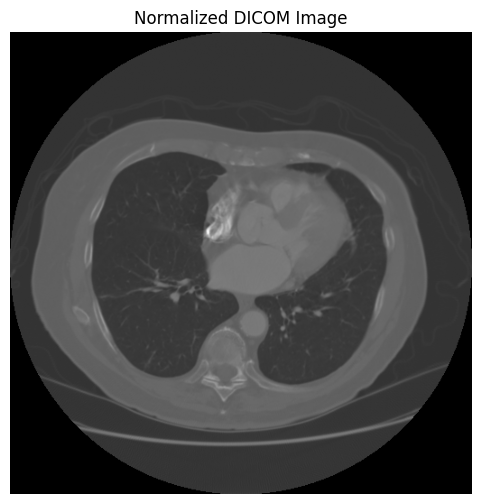

In [12]:
utils.show_image(
    normalized_image,
    title="Normalized DICOM Image"
)

Ukuran Subband:
LL : (256, 256)
LH : (256, 256)
HL : (256, 256)
HH : (256, 256)


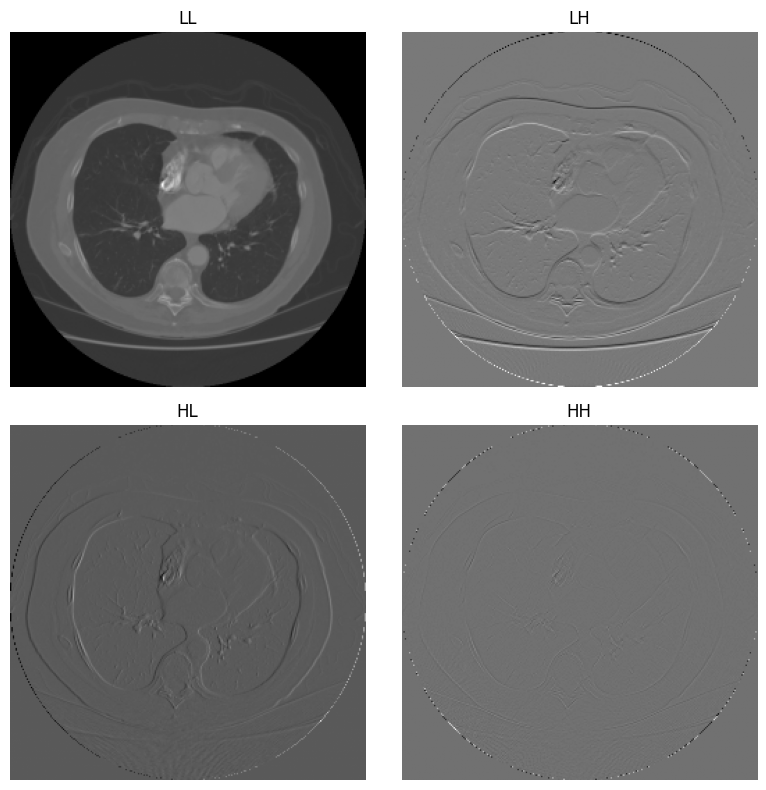

In [13]:
# Dekomposisi DWT Level-1
LL, LH, HL, HH = dwt.dwt_decompose(
    normalized_image,
    wavelet="haar"
)

print("Ukuran Subband:")
print("LL :", LL.shape)
print("LH :", LH.shape)
print("HL :", HL.shape)
print("HH :", HH.shape)

dwt.show_subbands(
    LL,
    LH,
    HL,
    HH
)

In [14]:
import pandas as pd
# Menampilkan matriks bagian tengah dari suatu subband.
def show_center_matrix(matrix, size=10, name="Subband"):
    rows, cols = matrix.shape

    center_row = rows // 2
    center_col = cols // 2

    half = size // 2

    patch = matrix[
        center_row-half:center_row+half,
        center_col-half:center_col+half
    ]

    print("=" * 60)
    print(f"{name} ({size}x{size} Center Matrix)")
    print("=" * 60)

    display(pd.DataFrame(np.round(patch, 4)))

show_center_matrix(LL, size=10, name="LL")
show_center_matrix(LH, size=10, name="LH")
show_center_matrix(HL, size=10, name="HL")
show_center_matrix(HH, size=10, name="HH")

LL (10x10 Center Matrix)


,0,1,2,3,4,5,6,7,8,9
0,242.5,241.5,241.5,241.5,243.0,241.0,241.0,240.5,240.0,238.5
1,243.0,242.5,241.5,242.0,242.0,243.0,240.0,241.5,240.0,240.5
2,241.0,242.0,242.0,243.5,241.5,243.0,241.0,241.5,242.0,240.0
3,240.0,244.0,242.0,243.0,241.0,243.0,242.5,241.0,242.0,240.0
4,240.5,243.0,242.0,242.5,243.0,242.5,242.5,242.5,241.5,240.0
5,241.5,242.0,243.5,242.0,243.0,241.5,241.5,242.5,243.5,241.0
6,240.0,242.0,243.0,242.0,242.5,242.5,243.5,243.0,242.5,240.5
7,240.0,240.5,242.5,241.0,243.0,242.5,241.0,242.5,241.5,242.5
8,240.5,241.5,240.5,243.0,242.5,242.0,241.0,242.5,243.5,243.0
9,238.5,241.5,241.5,241.0,241.0,242.0,241.5,243.5,240.5,242.0


LH (10x10 Center Matrix)


,0,1,2,3,4,5,6,7,8,9
0,-0.5,0.5,0.5,0.5,0.0,0.0,0.0,-0.5,0.0,-0.5
1,0.0,-0.5,0.5,0.0,1.0,0.0,1.0,-0.5,0.0,-0.5
2,0.0,-0.0,-1.0,-0.5,0.5,0.0,-1.0,-0.5,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,-1.0,0.0
4,-0.5,0.0,1.0,0.5,0.0,0.5,-0.5,0.5,0.5,0.0
5,0.5,0.0,-0.5,0.0,0.0,-0.5,-0.5,-0.5,-0.5,0.0
6,0.0,0.0,0.0,0.0,-0.5,-0.5,0.5,0.0,1.5,0.5
7,0.0,-0.5,0.5,0.0,0.0,0.5,0.0,-0.5,-0.5,0.5
8,-0.5,-0.5,-0.5,0.0,0.5,0.0,0.0,0.5,0.5,1.0
9,0.5,0.5,0.5,1.0,0.0,0.0,-0.5,-0.5,0.5,0.0


HL (10x10 Center Matrix)


,0,1,2,3,4,5,6,7,8,9
0,-0.5,0.5,-0.5,1.5,0.0,1.0,1.0,0.5,0.0,-0.5
1,-1.0,0.5,-0.5,0.0,0.0,1.0,1.0,-1.5,0.0,-0.5
2,-1.0,1.0,-1.0,-0.5,0.5,0.0,1.0,-0.5,0.0,0.0
3,0.0,0.0,0.0,1.0,1.0,-1.0,1.5,0.0,-1.0,0.0
4,0.5,-1.0,-1.0,-0.5,1.0,-0.5,2.5,-0.5,0.5,0.0
5,0.5,0.0,-0.5,0.0,1.0,0.5,0.5,-0.5,0.5,0.0
6,0.0,1.0,0.0,0.0,-0.5,-0.5,-0.5,-1.0,0.5,0.5
7,0.0,-0.5,-0.5,0.0,-1.0,-0.5,-1.0,0.5,0.5,-0.5
8,-0.5,-0.5,-0.5,-1.0,0.5,0.0,-1.0,0.5,-0.5,0.0
9,1.5,-0.5,0.5,0.0,1.0,0.0,-0.5,0.5,-0.5,0.0


HH (10x10 Center Matrix)


,0,1,2,3,4,5,6,7,8,9
0,0.5,-0.5,0.5,0.5,-1.0,0.0,0.0,-0.5,0.0,0.5
1,0.0,-0.5,0.5,0.0,1.0,0.0,0.0,0.5,0.0,0.5
2,0.0,1.0,-0.0,-0.5,-0.5,1.0,1.0,-0.5,0.0,0.0
3,-1.0,0.0,0.0,0.0,0.0,0.0,-0.5,1.0,-0.0,0.0
4,-0.5,0.0,0.0,-0.5,0.0,-0.5,-0.5,-0.5,-0.5,0.0
5,-0.5,0.0,-0.5,0.0,0.0,0.5,0.5,0.5,0.5,-1.0
6,0.0,-1.0,1.0,0.0,0.5,0.5,0.5,0.0,-0.5,0.5
7,0.0,0.5,-0.5,1.0,0.0,-0.5,0.0,-0.5,0.5,-0.5
8,0.5,-0.5,0.5,0.0,0.5,0.0,0.0,0.5,0.5,0.0
9,-0.5,0.5,-0.5,0.0,0.0,0.0,-0.5,0.5,-0.5,0.0


In [15]:
HL_scaled = embedding.prepare_subband(HL)

show_center_matrix(HL_scaled, size=10, name="HL (Scaled)")

HL (Scaled) (10x10 Center Matrix)


,0,1,2,3,4,5,6,7,8,9
0,-500,500,-500,1500,0,1000,1000,500,0,-500
1,-1000,500,-500,0,0,1000,1000,-1500,0,-500
2,-1000,1000,-1000,-500,500,0,1000,-500,0,0
3,0,0,0,1000,1000,-1000,1500,0,-1000,0
4,500,-1000,-1000,-500,1000,-500,2500,-500,500,0
5,500,0,-500,0,1000,500,500,-500,500,0
6,0,1000,0,0,-500,-500,-500,-1000,500,500
7,0,-500,-500,0,-1000,-500,-1000,500,500,-500
8,-500,-500,-500,-1000,500,0,-1000,500,-500,0
9,1500,-500,500,0,1000,0,-500,500,-500,0


In [16]:
# Hitung energi setiap subband
energies = energy.calculate_all_energies(
    LL,
    LH,
    HL,
    HH
)

# Tampilkan hasil
energy_df = energy.energy_dataframe(energies)

display(energy_df)

,Subband,Energy
0,LL,1.244082e+09
1,LH,1.119822e+06
2,HL,9.903378e+05
3,HH,2.387978e+05


ADAPTIVE SUBBAND SELECTION
Energi LH : 1119821.75
Energi HL : 990337.75

Subband Terpilih : LH


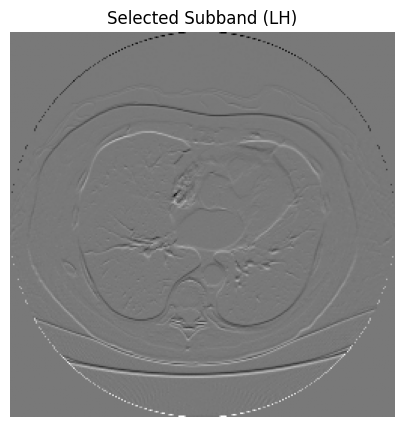

In [17]:
adaptive.adaptive_information(
    LH,
    HL
)

selected_name, selected_subband = adaptive.select_adaptive_subband(
    LH,
    HL
)

plt.figure(figsize=(5,5))
plt.imshow(selected_subband, cmap='gray')
plt.title(f"Selected Subband ({selected_name})")
plt.axis("off")
plt.show()

In [18]:
# Metadata menjadi string
metadata_string = str(metadata)

print("Panjang karakter:", len(metadata_string))
print("\n200 karakter pertama:\n")
print(metadata_string[:200])

Panjang karakter: 143

200 karakter pertama:

{'Patient ID': 'LIDC-IDRI-0001', 'Modality': 'CT', 'Slice Thickness': 2.5, 'Slice Location': -175.0, 'Pixel Spacing': ['0.703125', '0.703125']}


In [19]:
payload = embedding.prepare_payload(
    metadata_string
)
utils.print_metadata_summary(
    metadata,
    payload=None
)

METADATA SUMMARY
Number of Metadata Fields : 5
Metadata Characters       : 143
Metadata Bytes            : 143

Metadata Fields
--------------------------------------------------
Patient ID                    : LIDC-IDRI-0001
Modality                      : CT
Slice Thickness               : 2.5
Slice Location                : -175.0
Pixel Spacing                 : ['0.703125', '0.703125']


In [20]:
binary_payload = embedding.prepare_payload(
    metadata_string
)

print("Jumlah bit payload :", len(binary_payload))
print(binary_payload[:64])

Jumlah bit payload : 1176
0000000000000000000001000111100001111011001001110101000001100001


In [21]:
embedding.capacity_check(
    binary_payload,
    selected_subband
)

print("Capacity Check : Berhasil")

Capacity Check : Berhasil


In [22]:
scaled_subband = embedding.prepare_subband(
    selected_subband
)

print("Datatype :", scaled_subband.dtype)
print("Shape    :", scaled_subband.shape)
print("Minimum  :", scaled_subband.min())
print("Maximum  :", scaled_subband.max())

show_center_matrix(
    scaled_subband,
    size=10,
    name="Scaled Selected Subband"
)

Datatype : int32
Shape    : (256, 256)
Minimum  : -51500
Maximum  : 57000
Scaled Selected Subband (10x10 Center Matrix)


,0,1,2,3,4,5,6,7,8,9
0,-500,500,500,500,0,0,0,-500,0,-500
1,0,-500,500,0,1000,0,1000,-500,0,-500
2,0,0,-1000,-500,500,0,-1000,-500,0,0
3,1000,0,0,0,0,0,500,0,-1000,0
4,-500,0,1000,500,0,500,-500,500,500,0
5,500,0,-500,0,0,-500,-500,-500,-500,0
6,0,0,0,0,-500,-500,500,0,1500,500
7,0,-500,500,0,0,500,0,-500,-500,500
8,-500,-500,-500,0,500,0,0,500,500,1000
9,500,500,500,1000,0,0,-500,-500,500,0


In [23]:
embedded_scaled_subband = embedding.embed_lsb(
    scaled_subband,
    binary_payload
)

print("Embedding berhasil.")

difference = embedded_scaled_subband - scaled_subband

print("Jumlah koefisien berubah:",
      np.count_nonzero(difference))

changed = np.count_nonzero(embedded_scaled_subband != scaled_subband)

total = scaled_subband.size

print(f"Koefisien berubah : {changed}")
print(f"Total koefisien   : {total}")
print(f"Persentase        : {changed/total*100:.2f}%")

Embedding berhasil.
Jumlah koefisien berubah: 503
Koefisien berubah : 503
Total koefisien   : 65536
Persentase        : 0.77%


In [24]:
embedded_subband = embedding.restore_subband(
    embedded_scaled_subband
)

print(embedded_subband.dtype)
print(embedded_subband.shape)

LL_new = LL.copy()
LH_new = LH.copy()
HL_new = HL.copy()
HH_new = HH.copy()

if selected_name == "LH":
    LH_new = embedded_subband
else:
    HL_new = embedded_subband

reconstructed_image = dwt.dwt_reconstruct(
    LL_new,
    LH_new,
    HL_new,
    HH_new,
    wavelet="haar"
)

float64
(256, 256)


(512, 512)
uint8


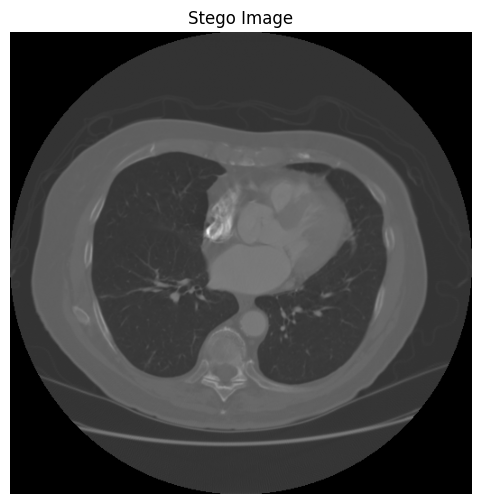

In [25]:
# Untuk evaluasi kualitas
stego_image = np.clip(reconstructed_image, 0, 255)
stego_image = stego_image.astype(np.uint8)

print(stego_image.shape)
print(stego_image.dtype)

utils.show_image(
    stego_image,
    title="Stego Image"
)

In [26]:
mse = evaluation.calculate_mse(
    normalized_image,
    stego_image
)

print(f"MSE : {mse:.6f}")

psnr = evaluation.calculate_psnr(
    normalized_image,
    stego_image
)

print(f"PSNR : {psnr:.4f} dB")

ssim = evaluation.calculate_ssim(
    normalized_image,
    stego_image
)

print(f"SSIM : {ssim:.6f}")
report = evaluation.evaluation_report(
    normalized_image,
    stego_image
)

report


MSE : 0.000847
PSNR : 78.8527 dB
SSIM : 0.999992


{'MSE': np.float64(0.00084686279296875),
 'PSNR': np.float64(78.85267308368933),
 'SSIM': np.float64(0.9999917601335886)}

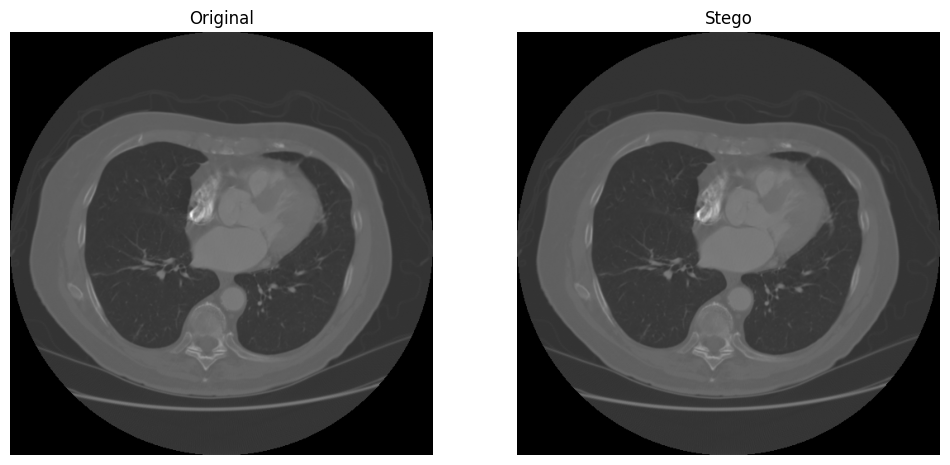

In [27]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(normalized_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(stego_image, cmap="gray")
plt.title("Stego")
plt.axis("off")

plt.show()

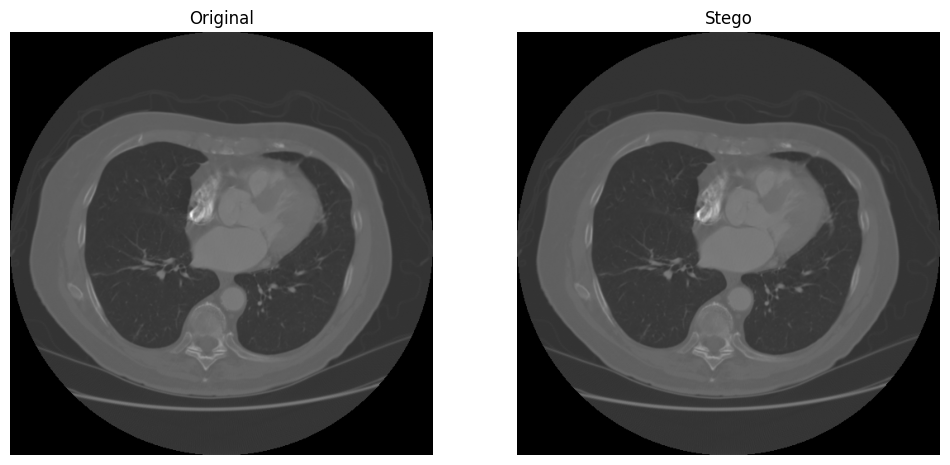

In [28]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(normalized_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(stego_image, cmap="gray")
plt.title("Stego")
plt.axis("off")

plt.show()

In [29]:
LL_s, LH_s, HL_s, HH_s = dwt.dwt_decompose(
    reconstructed_image,
    wavelet="haar"
)

if selected_name == "LH":
    stego_selected = LH_s
else:
    stego_selected = HL_s

extracted_metadata = extraction.extract_metadata(
    stego_selected
)

print("200 karakter pertama:\n")
print(extracted_metadata[:200])

200 karakter pertama:

{'Patient ID': 'LIDC-IDRI-0001', 'Modality': 'CT', 'Slice Thickness': 2.5, 'Slice Location': -175.0, 'Pixel Spacing': ['0.703125', '0.703125']}


In [30]:
original_binary = embedding.string_to_binary(metadata_string)

binary_stream = extraction.extract_lsb(stego_selected)

extracted_binary = extraction.extract_payload(binary_stream)

ber = evaluation.calculate_ber(
    original_binary,
    extracted_binary
)

print("BER =", ber)

BER = 0.0


DIFFERENCE STATISTICS
Changed Pixels     : 503
Total Pixels       : 65536
Percentage Changed : 0.7675%
Maximum Difference : 1
Mean Difference    : 0.006912


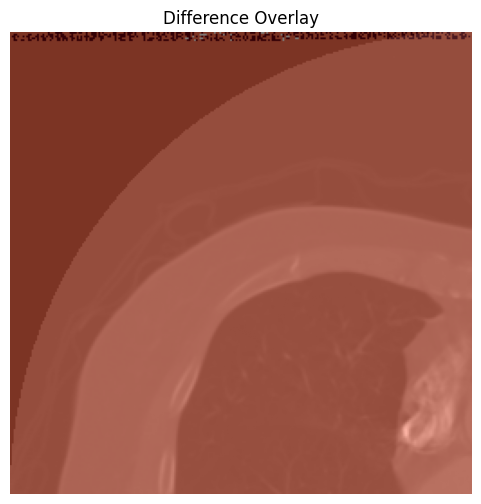

In [31]:
utils.print_difference_statistics(
    difference
)
utils.show_difference_overlay(
    normalized_image,
    difference
)

In [32]:
!pwd

/content/drive/MyDrive/TugasAkhirKayla


In [38]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   exp1.ipynb
	modified:   expbatch.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	TAAKAYY.drawio (1).png
	link github.gdoc

no changes added to commit (use "git add" and/or "git commit -a")


In [35]:
!find . -name "*.ipynb"

./expbatch.ipynb
./exp1.ipynb


In [37]:
!ls

 Dataset		'link github.gdoc'   Output
 exp1.ipynb		'main (18).pdf'      sempro
 expbatch.ipynb		'main (22).pdf'     'TAAKAYY.drawio (1).png'
'Jurnal Referensi Fix'	 Modules


In [ ]:
%cd /content/drive/MyDrive/TugasAkhirKayla

!git add exp1.ipynb expbatch.ipynb

In [ ]:
!git commit -m "Update experiment notebooks and visualization"
